# Objective :- The objective of this project is to build a binary classification model that can predict whether a movie review is positive or negative based on its text content.

# LSTM 
Normally ML models doesn't understand the word order unless we manually convert text into features so we used LSTM it works well with sequence data beacause it can remember the previous important words of a sentence. It captures context better than basic models.

Example - The movie is not good,
the word "not" changes the sentiment completely.

# Load the dataset from keras

In [3]:
from tensorflow.keras.datasets import imdb

In [4]:
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=5000)
# num_words = 5000 that means it will keep only the top 5000 most frequent words appear in the dataset.
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

c:\Users\baran\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_format_impl.py:838: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  array = pickle.load(fp, **pickle_kwargs)


(25000,)
(25000,)
(25000,)
(25000,)


# Since i used the IMDb movie review dataset from keras so the dataset is not loaded as raw text. it is loaded as integer-encoded sequences which means that each review is already converted into numbers where each number represents the length of particular word.

In [5]:
print(X_train[0])

[1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 2, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 2, 15, 256, 4, 2, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 2, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 2, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 2, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 1334, 88, 12, 16, 283, 5, 16, 4472, 113, 103, 32, 15, 16, 2, 19, 178, 32]


In [6]:
print(y_train[0])

1


The problem with sequence length is not all reviews have the same length of words. some reviews are short while some are long. But Neural networks need input data to have the same shape. 
So if one review is having 50 words and the other review is having 75 words then we cann't directly feed them together into LSTM. In that case we need Padding

In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
maxlen = 200
X_train = pad_sequences(X_train, maxlen=maxlen)
X_test = pad_sequences(X_test, maxlen=maxlen)

Now it makes each review's length as 200. 
If the review's length is less than 200 then it will add zeros
If the review's length is more than 200 then it will truncate to make it 200.

# Building the model

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Input
model = Sequential([
    Input(shape=(maxlen,)), # each training sample is sequence of 200 int.
    Embedding(input_dim=5000, output_dim=128),
    LSTM(64),
    Dense(1, activation='sigmoid')
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 128)       │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 689,473 (2.63 MB)

 Trainable params: 689,473 (2.63 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
history = model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 24s 71ms/step - accuracy: 0.7930 - loss: 0.4442 - val_accuracy: 0.8598 - val_loss: 0.3387
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 23s 72ms/step - accuracy: 0.8874 - loss: 0.2808 - val_accuracy: 0.8700 - val_loss: 0.3183
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 21s 67ms/step - accuracy: 0.9148 - loss: 0.2205 - val_accuracy: 0.8654 - val_loss: 0.3508
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 21s 68ms/step - accuracy: 0.9324 - loss: 0.1808 - val_accuracy: 0.8612 - val_loss: 0.3430
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 56ms/step - accuracy: 0.9405 - loss: 0.1559 - val_accuracy: 0.8634 - val_loss: 0.3776


In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", accuracy)

782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.8633 - loss: 0.3784
Test Accuracy: 0.8632799983024597


In [ ]:
print("Test Loss:", loss)

Test Loss: 0.37840786576271057


In [13]:
pred = model.predict(X_test[:5])
print(pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
[[0.29187658]
 [0.99907434]
 [0.48849034]
 [0.6569077 ]
 [0.99976313]]


In [14]:
y_pred = (model.predict(X_test) > 0.5).astype("int32")
print(y_pred[:10])

782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step
[[0]
 [1]
 [0]
 [1]
 [1]
 [1]
 [1]
 [0]
 [1]
 [1]]


In [15]:
import matplotlib.pyplot as plt

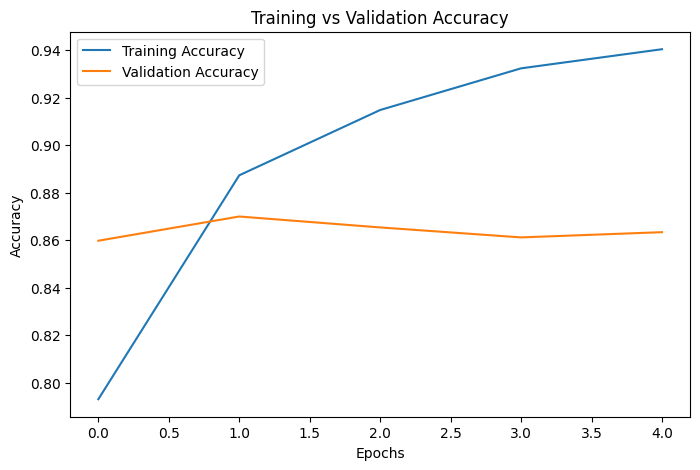

In [16]:
# Accuracy graph
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

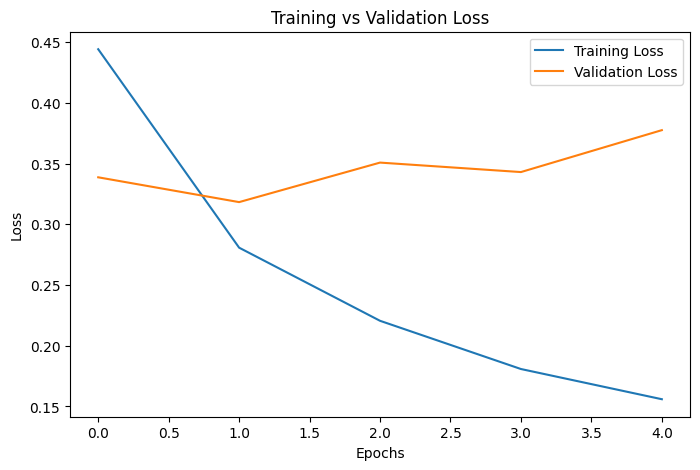

In [17]:
# Loss graph
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [18]:
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype("int32")

782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step


In [19]:
y_pred = y_pred.flatten()
y_pred

array([0, 1, 0, ..., 0, 0, 1], shape=(25000,), dtype=int32)

[[10437  2063]
 [ 1355 11145]]


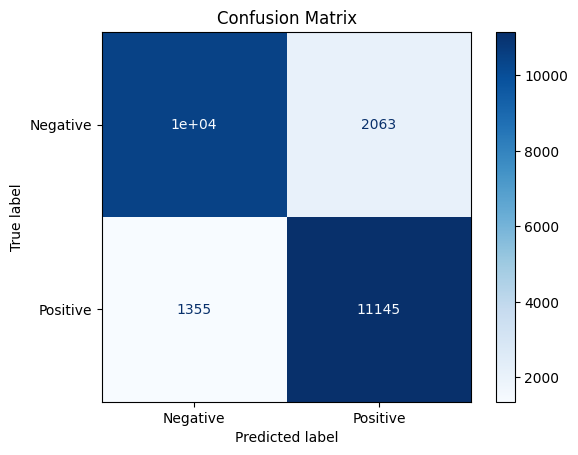

In [20]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Negative', 'Positive'])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

[tn    fp]

[fn    tp]

TN - Negative reviews is predicted as negative = 10437

TP - Possitive review is predicted as possitive = 11145

FP - Negative review is predicted as Possitive = 2063

FN - possitive review is predicted as negative = 1355

So overall the model is doing good job.

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

              precision    recall  f1-score   support

    Negative       0.89      0.83      0.86     12500
    Positive       0.84      0.89      0.87     12500

    accuracy                           0.86     25000
   macro avg       0.86      0.86      0.86     25000
weighted avg       0.86      0.86      0.86     25000

